# 101 -- PDX-2 NB Full Analysis from K-Sweep

This notebook mirrors the "sweep -> fixed-K full analysis" pattern used by notebook 14 for notebook 13.

Workflow:
1. Choose `SELECT_K` from the PDX sweep.
2. Automatically pick the best seed run for that K (or override manually).
3. Run full analysis and save figure panels (`fig1`..`fig10`) to `reports/`.
4. Generate a markdown report and optional PDF.


In [1]:
from pathlib import Path
import sys


def _find_repo_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for path in candidates:
        if (path / 'pyproject.toml').exists() and (path / 'src' / 'cytof_archetypes').exists():
            return path
    fallback = Path('/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv')
    if (fallback / 'src' / 'cytof_archetypes').exists():
        return fallback
    raise RuntimeError('Could not locate repository root')


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

print('Repo root:', REPO_ROOT)


Repo root: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv


In [2]:
import json
import re
import warnings
import subprocess

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 140,
    'savefig.dpi': 220,
    'savefig.bbox': 'tight',
})

# ------------------------- User Controls -------------------------
SELECT_K = 5               # choose K from sweep (4,5,6,7,8)
SELECT_SEED = 'best'       # 'best' or integer seed (e.g., 42)
FORCE_RECOMPUTE_UMAP = False
MAX_CELLS_FOR_PLOTTING = 100_000
TOP_GENES_PER_ARCH = 12

SWEEP_RUNS_DIR = REPO_ROOT / 'outputs' / 'pdx2_scrna_nb_k_sweep' / 'runs'
H5AD_PATH = REPO_ROOT / 'data' / 'pdx2_scrna_hvg_counts.h5ad'

OUT_DIR = REPO_ROOT / f'reports/pdx2_nb_k{SELECT_K}'
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Sweep runs:', SWEEP_RUNS_DIR)
print('h5ad path :', H5AD_PATH)
print('Report dir:', OUT_DIR)


Sweep runs: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/pdx2_scrna_nb_k_sweep/runs
h5ad path : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/pdx2_scrna_hvg_counts.h5ad
Report dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/reports/pdx2_nb_k5


In [3]:
# Resolve selected run from sweep outputs
assert SWEEP_RUNS_DIR.exists(), f'Missing sweep run directory: {SWEEP_RUNS_DIR}'

run_rows = []
pat = re.compile(r'^k(?P<k>\d+)_seed(?P<seed>\d+)$')

for p in sorted(SWEEP_RUNS_DIR.iterdir()):
    if not p.is_dir():
        continue
    m = pat.match(p.name)
    if m is None:
        continue
    k = int(m.group('k'))
    seed = int(m.group('seed'))

    hist_path = p / 'training_log.csv'
    if not hist_path.exists():
        continue
    hist = pd.read_csv(hist_path)

    if 'val_recon' in hist.columns:
        best_val = float(hist['val_recon'].min())
        best_col = 'val_recon'
    elif 'val_nll' in hist.columns:
        best_val = float(hist['val_nll'].min())
        best_col = 'val_nll'
    else:
        best_val = float(hist['val_loss'].min())
        best_col = 'val_loss'

    run_rows.append({
        'k': k,
        'seed': seed,
        'run_dir': p,
        'best_val': best_val,
        'best_col': best_col,
        'n_epochs': int(len(hist)),
    })

runs_df = pd.DataFrame(run_rows)
if len(runs_df) == 0:
    raise RuntimeError('No completed runs found in sweep directory.')

runs_k = runs_df[runs_df['k'] == int(SELECT_K)].copy()
if len(runs_k) == 0:
    raise RuntimeError(f'No runs found for K={SELECT_K}. Available K: {sorted(runs_df.k.unique().tolist())}')

if SELECT_SEED == 'best':
    pick = runs_k.sort_values('best_val', ascending=True).iloc[0]
else:
    seed_int = int(SELECT_SEED)
    sub = runs_k[runs_k['seed'] == seed_int]
    if len(sub) == 0:
        raise RuntimeError(f'No run found for K={SELECT_K}, seed={seed_int}')
    pick = sub.iloc[0]

RUN_DIR = Path(pick['run_dir'])
SEED = int(pick['seed'])
BEST_COL = str(pick['best_col'])

print('Selected run:', RUN_DIR)
print(f'K={SELECT_K}, seed={SEED}, best {BEST_COL}={pick.best_val:.6f}')
print('\nAll runs for selected K:')
display(runs_k.sort_values('best_val').reset_index(drop=True))


Selected run: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/pdx2_scrna_nb_k_sweep/runs/k5_seed42
K=5, seed=42, best val_recon=52.653094

All runs for selected K:


,k,seed,run_dir,best_val,best_col,n_epochs
0,5,42,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...,52.653094,val_recon,1096


In [4]:
# Load run artifacts + processed data
assert H5AD_PATH.exists(), f'Missing H5AD: {H5AD_PATH}'
adata = sc.read_h5ad(H5AD_PATH)
print(f'h5ad loaded: {adata.n_obs:,} cells x {adata.n_vars:,} genes')

fractions_path = RUN_DIR / 'archetypes' / 'archetype_gene_fractions.csv'
logits_path = RUN_DIR / 'archetypes' / 'archetype_logits.csv'
theta_path = RUN_DIR / 'archetypes' / 'gene_dispersion.csv'
hist_path = RUN_DIR / 'training_log.csv'
weights_all_path = RUN_DIR / 'weights' / 'cell_weights.csv'

for p in [fractions_path, logits_path, theta_path, hist_path, weights_all_path]:
    if not p.exists():
        raise FileNotFoundError(f'Missing expected artifact: {p}')

fractions = pd.read_csv(fractions_path, index_col=0)
logits = pd.read_csv(logits_path, index_col=0)
theta_df = pd.read_csv(theta_path)
hist = pd.read_csv(hist_path)
weights_all = pd.read_csv(weights_all_path)

K = fractions.shape[0]
W_COLS = [c for c in weights_all.columns if c.startswith('w_')]
assert len(W_COLS) == K, f'Expected {K} weight columns, found {len(W_COLS)}'

COMP_NAMES = [f'A{i}' for i in range(K)]
fractions.index = COMP_NAMES
logits.index = COMP_NAMES

print('Archetypes:', COMP_NAMES)
print('Training epochs:', len(hist))
print('Best val metric:', hist[BEST_COL].min())
print('Weights rows:', len(weights_all))


h5ad loaded: 8,632 cells x 200 genes
Archetypes: ['A0', 'A1', 'A2', 'A3', 'A4']
Training epochs: 1096
Best val metric: 52.653093875605165
Weights rows: 8632


In [5]:
# Align weights to adata and compute derived fields
if 'cell_id' in adata.obs.columns:
    adata.obs['cell_id'] = adata.obs['cell_id'].astype(str)
else:
    adata.obs['cell_id'] = adata.obs_names.astype(str)

w = weights_all.copy()
w['cell_id'] = w['cell_id'].astype(str)

obs_df = adata.obs[['cell_id']].copy()
obs_df = obs_df.reset_index().rename(columns={'index': 'obs_name'})
merged = obs_df.merge(w, on='cell_id', how='inner')

if len(merged) == 0:
    raise RuntimeError('No aligned cells between H5AD and weight table.')

W = merged[W_COLS].to_numpy(dtype=float)
merged['dominant'] = np.argmax(W, axis=1)
merged['dominant_name'] = merged['dominant'].map({i: f'A{i}' for i in range(K)})
merged['entropy'] = -(np.clip(W, 1e-12, 1.0) * np.log(np.clip(W, 1e-12, 1.0))).sum(axis=1)
merged['effective_k'] = np.exp(merged['entropy'])

# Attach per-cell fields back to adata.obs (aligned subset)
adata_sub = adata[merged['obs_name'].values].copy()
for col in ['split', 'dominant', 'dominant_name', 'entropy', 'effective_k', *W_COLS]:
    adata_sub.obs[col] = merged[col].values

print(f'Aligned cells: {adata_sub.n_obs:,} / {adata.n_obs:,}')
print('Split counts:')
print(adata_sub.obs['split'].value_counts())


Aligned cells: 8,632 / 8,632
Split counts:
split
train    6042
val      1295
test     1295
Name: count, dtype: int64


In [6]:
# UMAP for visualization (on log1p-normalized counts)
if FORCE_RECOMPUTE_UMAP or ('X_umap' not in adata_sub.obsm):
    adata_vis = adata_sub.copy()

    # Use sparse count matrix safely
    if sparse.issparse(adata_vis.X):
        X_counts = adata_vis.X.copy().astype(np.float32)
    else:
        X_counts = np.asarray(adata_vis.X, dtype=np.float32)

    adata_vis.layers['counts'] = X_counts
    sc.pp.normalize_total(adata_vis, target_sum=1e4)
    sc.pp.log1p(adata_vis)
    sc.pp.pca(adata_vis, n_comps=min(50, adata_vis.n_vars - 1))
    sc.pp.neighbors(adata_vis, n_neighbors=15, n_pcs=min(30, adata_vis.obsm['X_pca'].shape[1]))
    sc.tl.umap(adata_vis, random_state=42)

    adata_sub.obsm['X_umap'] = adata_vis.obsm['X_umap'].copy()

print('UMAP ready:', 'X_umap' in adata_sub.obsm)


UMAP ready: True


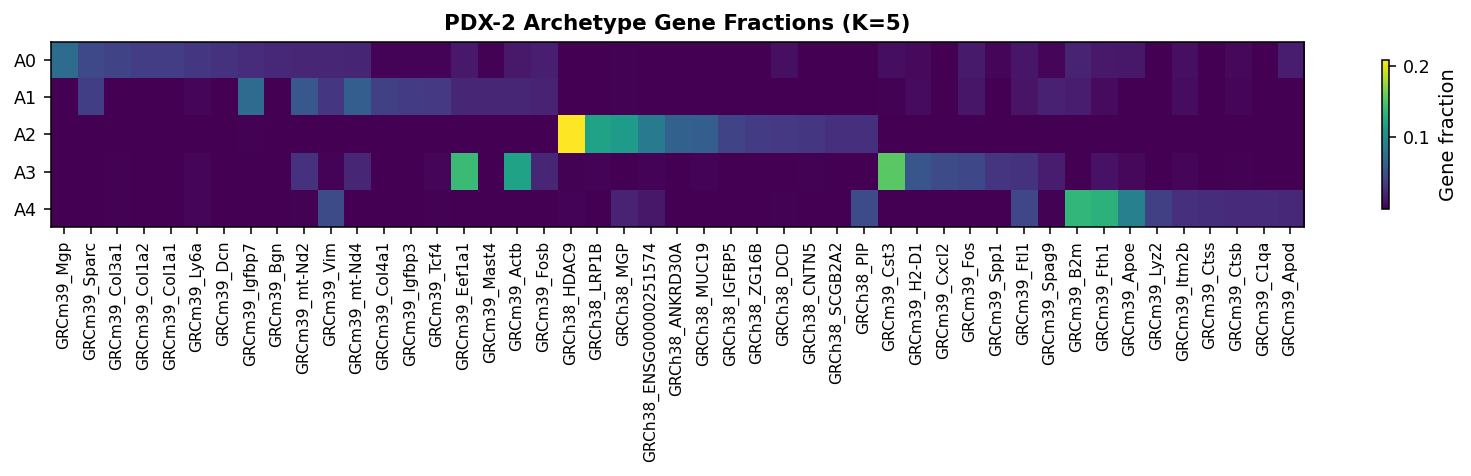

Saved fig1


In [7]:
# Figure 1: Archetype top-gene fraction heatmap
selected_genes = []
for arch in COMP_NAMES:
    top = fractions.loc[arch].sort_values(ascending=False).head(TOP_GENES_PER_ARCH).index.tolist()
    selected_genes.extend(top)

# keep order and uniqueness
seen = set()
gene_panel = []
for g in selected_genes:
    if g not in seen:
        seen.add(g)
        gene_panel.append(g)

mat = fractions[gene_panel]
fig, ax = plt.subplots(figsize=(max(10, len(gene_panel) * 0.25), max(3.5, K * 0.55)))
im = ax.imshow(mat.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(gene_panel)))
ax.set_xticklabels(gene_panel, rotation=90, fontsize=8)
ax.set_yticks(range(K))
ax.set_yticklabels(COMP_NAMES)
ax.set_title(f'PDX-2 Archetype Gene Fractions (K={K})', fontweight='bold')
plt.colorbar(im, ax=ax, label='Gene fraction', shrink=0.8)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_archetype_heatmap.png')
fig.savefig(FIG_DIR / 'fig1_archetype_heatmap.pdf')
plt.show()
print('Saved fig1')


In [ ]:
# Figure 2: Training convergence
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
best_epoch = int(hist[BEST_COL].idxmin())

axes[0].plot(hist.index, hist['train_recon'] if 'train_recon' in hist.columns else hist['train_loss'],
             label='Train', color='steelblue', lw=1.6, alpha=0.85)
axes[0].plot(hist.index, hist[BEST_COL], label='Val', color='tomato', lw=1.6)
axes[0].axvline(best_epoch, color='gray', ls='--', lw=1, label=f'Best epoch {best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel(BEST_COL)
axes[0].set_title('Full training run')
axes[0].legend()

n_tail = min(150, len(hist))
tail = hist.tail(n_tail)
axes[1].plot(tail.index, tail['train_recon'] if 'train_recon' in tail.columns else tail['train_loss'],
             color='steelblue', lw=1.6, alpha=0.85, label='Train')
axes[1].plot(tail.index, tail[BEST_COL], color='tomato', lw=1.6, label='Val')
axes[1].axvline(best_epoch, color='gray', ls='--', lw=1)
axes[1].set_title(f'Final {n_tail} epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

fig.suptitle(f'NB-PAE Training Convergence (K={K}, seed={SEED})', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_training_convergence.png')
fig.savefig(FIG_DIR / 'fig2_training_convergence.pdf')
plt.show()
print('Saved fig2')


In [ ]:
# Figure 3: UMAP colored by dominant archetype and effective K
coords = adata_sub.obsm['X_umap']

if adata_sub.n_obs > MAX_CELLS_FOR_PLOTTING:
    rng = np.random.default_rng(42)
    idx = rng.choice(adata_sub.n_obs, size=MAX_CELLS_FOR_PLOTTING, replace=False)
else:
    idx = np.arange(adata_sub.n_obs)

coords_s = coords[idx]
dom_s = adata_sub.obs['dominant'].to_numpy()[idx]
eff_s = adata_sub.obs['effective_k'].to_numpy()[idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

palette = sns.color_palette('tab10', K)
for k_i in range(K):
    m = dom_s == k_i
    axes[0].scatter(coords_s[m, 0], coords_s[m, 1], s=4, alpha=0.65, color=palette[k_i], label=f'A{k_i}')
axes[0].set_title('UMAP by Dominant Archetype')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')
axes[0].legend(markerscale=3, fontsize=8, frameon=False)

scm = axes[1].scatter(coords_s[:, 0], coords_s[:, 1], c=eff_s, s=4, alpha=0.7, cmap='viridis')
axes[1].set_title('UMAP by Effective K')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
plt.colorbar(scm, ax=axes[1], label='Effective K', shrink=0.8)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_umap_composition.png')
fig.savefig(FIG_DIR / 'fig3_umap_composition.pdf')
plt.show()
print('Saved fig3')


In [ ]:
# Figure 4: Composition by split
split_mean = adata_sub.obs.groupby('split')[W_COLS].mean().reindex(['train', 'val', 'test']).fillna(0)
split_mean.columns = COMP_NAMES

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# stacked bars
x = np.arange(len(split_mean.index))
bottom = np.zeros(len(x))
for i, comp in enumerate(COMP_NAMES):
    vals = split_mean[comp].values
    axes[0].bar(x, vals, bottom=bottom, color=palette[i], label=comp, edgecolor='white', linewidth=0.4)
    bottom += vals
axes[0].set_xticks(x)
axes[0].set_xticklabels(split_mean.index)
axes[0].set_ylim(0, 1.02)
axes[0].set_ylabel('Mean weight')
axes[0].set_title('Mean Archetype Weights by Split')
axes[0].legend(fontsize=8, frameon=False, loc='upper right')

# heatmap
im = axes[1].imshow(split_mean.values, aspect='auto', cmap='Oranges', vmin=0, vmax=max(0.35, float(split_mean.values.max())))
axes[1].set_xticks(range(K))
axes[1].set_xticklabels(COMP_NAMES, rotation=45, ha='right')
axes[1].set_yticks(range(len(split_mean.index)))
axes[1].set_yticklabels(split_mean.index)
axes[1].set_title('Split x Archetype Heatmap')
for i in range(split_mean.shape[0]):
    for j in range(split_mean.shape[1]):
        v = split_mean.iloc[i, j]
        axes[1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                     color='white' if v > 0.22 else 'black')
plt.colorbar(im, ax=axes[1], label='Mean weight', shrink=0.85)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig4_split_composition.png')
fig.savefig(FIG_DIR / 'fig4_split_composition.pdf')
plt.show()
print('Saved fig4')


In [ ]:
# Figure 5: Archetype weight pairwise relationships
W = adata_sub.obs[W_COLS].to_numpy(dtype=float)
corr = np.corrcoef(W.T)

fig, axes = plt.subplots(K, K, figsize=(2.1 * K + 2, 2.1 * K + 2))
for i in range(K):
    for j in range(K):
        ax = axes[i, j]
        if i == j:
            ax.hist(W[:, i], bins=50, color=palette[i], alpha=0.85, density=True)
            ax.set_xlim(0, 1)
        else:
            ax.hexbin(W[:, j], W[:, i], gridsize=35, cmap='Blues', mincnt=1)
            ax.text(0.05, 0.9, f'r={corr[i,j]:.2f}', transform=ax.transAxes, fontsize=7, color='darkred')
        if i == K - 1:
            ax.set_xlabel(f'A{j}', fontsize=8)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(f'A{i}', fontsize=8)
        else:
            ax.set_yticklabels([])

fig.suptitle('Archetype Weight Pairwise Relationships', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig5_weight_correlations.png')
fig.savefig(FIG_DIR / 'fig5_weight_correlations.pdf')
plt.show()

print(pd.DataFrame(corr, index=COMP_NAMES, columns=COMP_NAMES).round(3).to_string())
print('Saved fig5')


In [ ]:
# Figure 6: Effective K
eff = adata_sub.obs['effective_k'].to_numpy(dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(eff, bins=80, color='steelblue', alpha=0.85, density=True)
axes[0].axvline(eff.mean(), color='red', ls='--', lw=1.2, label=f'Mean={eff.mean():.2f}')
axes[0].set_xlabel('Effective K')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Effective K (n={len(eff):,})')
axes[0].legend()

by_split = adata_sub.obs.groupby('split')['effective_k'].agg(['mean', 'std']).reindex(['train', 'val', 'test'])
axes[1].bar(range(len(by_split)), by_split['mean'].values, yerr=by_split['std'].fillna(0).values,
            capsize=4, color=['#4c78a8', '#f58518', '#54a24b'], alpha=0.8)
axes[1].set_xticks(range(len(by_split)))
axes[1].set_xticklabels(by_split.index)
axes[1].set_ylabel('Mean effective K')
axes[1].set_ylim(0, max(1.05 * by_split['mean'].max(), float(K)))
axes[1].set_title('Effective K by split')

fig.suptitle('Polyphenic Mixing via Effective K', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig6_effective_k.png')
fig.savefig(FIG_DIR / 'fig6_effective_k.pdf')
plt.show()
print(f'Mean effective K: {eff.mean():.3f}')
print('Saved fig6')


In [ ]:
# Figure 7: Top genes per archetype (horizontal bars)
fig, axes = plt.subplots(K, 1, figsize=(10, max(2.5 * K, 6)), sharex=False)
if K == 1:
    axes = [axes]

for i, arch in enumerate(COMP_NAMES):
    top = fractions.loc[arch].sort_values(ascending=False).head(10)
    axes[i].barh(np.arange(len(top))[::-1], top.values, color=palette[i], alpha=0.85)
    axes[i].set_yticks(np.arange(len(top))[::-1])
    axes[i].set_yticklabels(top.index, fontsize=8)
    axes[i].set_xlabel('Gene fraction')
    axes[i].set_title(f'{arch} top genes')

fig.suptitle('Top Genes by Archetype', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig7_top_genes.png')
fig.savefig(FIG_DIR / 'fig7_top_genes.pdf')
plt.show()
print('Saved fig7')


In [ ]:
# Figure 8: Weight distributions by split (violin)
fig, axes = plt.subplots(1, K, figsize=(max(12, 2.5 * K), 4.5), sharey=True)
if K == 1:
    axes = [axes]

for i, comp_col in enumerate(W_COLS):
    ax = axes[i]
    data = [
        adata_sub.obs.loc[adata_sub.obs['split'] == s, comp_col].to_numpy(dtype=float)
        for s in ['train', 'val', 'test']
    ]
    vp = ax.violinplot(data, positions=[0, 1, 2], showmedians=True, showextrema=False)
    for body in vp['bodies']:
        body.set_facecolor(palette[i])
        body.set_alpha(0.75)
    vp['cmedians'].set_color('black')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['train', 'val', 'test'], rotation=25)
    ax.set_title(f'A{i}')
    ax.set_ylim(0, 1)
    if i == 0:
        ax.set_ylabel('Weight')

fig.suptitle('Per-Archetype Weight Distributions by Split', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig8_weight_distributions.png')
fig.savefig(FIG_DIR / 'fig8_weight_distributions.pdf')
plt.show()
print('Saved fig8')


In [ ]:
# Figure 9: NB per-cell reconstruction diagnostics (val/test)
per_cell_frames = []
for split in ['val', 'test']:
    p = RUN_DIR / 'metrics' / f'{split}_per_cell_loss.csv'
    if p.exists():
        df = pd.read_csv(p)
        df['split'] = split
        per_cell_frames.append(df)

if len(per_cell_frames) == 0:
    print('No per-cell NB diagnostics found; skipping fig9.')
else:
    per_cell = pd.concat(per_cell_frames, ignore_index=True)

    # library size from h5ad aligned cells
    if sparse.issparse(adata_sub.X):
        libsize = np.asarray(adata_sub.X.sum(axis=1)).ravel()
    else:
        libsize = np.asarray(adata_sub.X.sum(axis=1)).ravel()
    lib_map = pd.Series(libsize, index=adata_sub.obs['cell_id'].astype(str)).to_dict()
    per_cell['library_size'] = per_cell['cell_id'].astype(str).map(lib_map)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

    sns.violinplot(data=per_cell, x='split', y='nb_nll', ax=axes[0], inner='quartile', palette='Set2', cut=0)
    axes[0].set_title('Per-cell NB NLL by split')
    axes[0].set_ylabel('NB NLL')

    x = np.log10(np.clip(per_cell['library_size'].to_numpy(dtype=float), 1, None))
    y = per_cell['nb_nll'].to_numpy(dtype=float)
    axes[1].scatter(x, y, s=6, alpha=0.25, color='tab:blue')
    if np.isfinite(x).sum() > 10 and np.isfinite(y).sum() > 10:
        r, p = spearmanr(x, y)
        axes[1].text(0.03, 0.94, f'Spearman r={r:.2f}, p={p:.2e}', transform=axes[1].transAxes, fontsize=9)
    axes[1].set_xlabel('log10(library size)')
    axes[1].set_ylabel('NB NLL')
    axes[1].set_title('NB NLL vs Library Size')

    plt.tight_layout()
    fig.savefig(FIG_DIR / 'fig9_nb_diagnostics.png')
    fig.savefig(FIG_DIR / 'fig9_nb_diagnostics.pdf')
    plt.show()
    print('Saved fig9')


In [ ]:
# Figure 10: Gene dispersion summary
th = theta_df.copy()
th = th.sort_values('theta', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

axes[0].hist(np.log1p(th['theta'].values), bins=60, color='darkorange', alpha=0.85)
axes[0].set_xlabel('log1p(theta)')
axes[0].set_ylabel('Genes')
axes[0].set_title('Gene dispersion distribution')

n_top = 20
top = th.head(n_top).iloc[::-1]
axes[1].barh(top['gene'], top['theta'], color='teal', alpha=0.85)
axes[1].set_xlabel('theta')
axes[1].set_title(f'Top {n_top} dispersed genes')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig10_gene_dispersion.png')
fig.savefig(FIG_DIR / 'fig10_gene_dispersion.pdf')
plt.show()
print('Saved fig10')


In [ ]:
# Generate markdown + optional PDF report

n_cells = int(adata_sub.n_obs)
n_genes = int(adata_sub.n_vars)
mean_eff = float(adata_sub.obs['effective_k'].mean())
poly_frac = float((adata_sub.obs['effective_k'] >= 1.5).mean())
best_val = float(hist[BEST_COL].min())
best_epoch = int(hist[BEST_COL].idxmin())

split_tbl = (
    adata_sub.obs.groupby('split')[W_COLS + ['effective_k']]
    .mean()
    .rename(columns={f'w_{i}': f'A{i}' for i in range(K)})
)

lines = []
lines.append('---')
lines.append(f'title: "PDX-2 scRNA NB Archetype Analysis (K={K}, seed={SEED})"')
lines.append('author: "Guy Ron"')
lines.append('date: "April 2026"')
lines.append('geometry: margin=2.5cm')
lines.append('fontsize: 10pt')
lines.append('linestretch: 1.15')
lines.append('---')
lines.append('')
lines.append('# Summary')
lines.append('')
lines.append(
    f'This report analyzes the selected NB-PAE sweep run for PDX-2 scRNA-seq: '
    f'K={K}, seed={SEED}, best {BEST_COL}={best_val:.4f} at epoch {best_epoch}. '
    f'The aligned dataset includes {n_cells:,} cells and {n_genes:,} HVGs.'
)
lines.append('')
lines.append(
    f'Mean effective K is {mean_eff:.2f}, with {poly_frac:.1%} of cells showing polyphenic mixing '
    f'(effective K >= 1.5).'
)
lines.append('')
lines.append('# Mean Composition by Split')
lines.append('')
lines.append(split_tbl.round(3).to_markdown())
lines.append('')
lines.append('# Figures')
lines.append('')
for i, caption in [
    (1, 'Archetype top-gene fraction heatmap'),
    (2, 'Training convergence'),
    (3, 'UMAP composition'),
    (4, 'Composition by split'),
    (5, 'Weight pairwise relationships'),
    (6, 'Effective K distribution'),
    (7, 'Top genes per archetype'),
    (8, 'Weight distributions by split'),
    (9, 'NB reconstruction diagnostics'),
    (10, 'Gene dispersion summary'),
]:
    png_rel = f'figures/fig{i}_{[p for p in FIG_DIR.glob(f"fig{i}_*.png")][0].name.split("fig{i}_",1)[1]}' if any(FIG_DIR.glob(f'fig{i}_*.png')) else None
    if png_rel is None:
        continue
    lines.append(f'## Figure {i}: {caption}')
    lines.append('')
    lines.append(f'![Figure {i}]({png_rel})')
    lines.append('')

report_md = OUT_DIR / 'report.md'
report_pdf = OUT_DIR / 'report.pdf'
OUT_DIR.mkdir(parents=True, exist_ok=True)
report_md.write_text('\n'.join(lines), encoding='utf-8')
print('Wrote markdown report:', report_md)

try:
    cmd = ['pandoc', str(report_md), '-o', str(report_pdf)]
    subprocess.run(cmd, check=True, capture_output=True, text=True)
    print('Wrote PDF report:', report_pdf)
except Exception as e:
    print('PDF generation skipped (pandoc unavailable or failed):', e)
